In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('./Churn_Modelling.csv')
df.head()

In [ ]:
df.info()

In [ ]:
df.duplicated()

In [ ]:
df['Exited'].value_counts()

In [ ]:
df['Geography'].value_counts()

In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [78]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [82]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7305 - loss: 0.5712 - val_accuracy: 0.7969 - val_loss: 0.4921
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8000 - loss: 0.4695 - val_accuracy: 0.8181 - val_loss: 0.4424
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8109 - loss: 0.4365 - val_accuracy: 0.8300 - val_loss: 0.4182
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8233 - loss: 0.4162 - val_accuracy: 0.8381 - val_loss: 0.4029
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8327 - loss: 0.3996 - val_accuracy: 0.8444 - val_loss: 0.3898
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8405 - loss: 0.3852 - val_accuracy: 0.8494 - val_loss: 0.3794
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8491 - loss: 0.3730 - val_accuracy: 0.8544 - val_loss: 0.3707
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8545 - loss: 0.3636 - val_accu

In [83]:
model.accuracy = model.evaluate(X_test_scaled,y_test)[1]
model.accuracy

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8570 - loss: 0.3382


0.8569999933242798

In [84]:
model.layers[0].get_weights()

[array([[ 0.47801197,  0.02507526, -0.30030182, -0.6477922 , -0.16652274,
         -0.02593583,  0.01088925,  0.3888084 , -0.07567282,  0.10424275,
         -0.02225075],
        [-0.03972081,  0.2682842 , -0.46220738,  0.27550584,  0.03999292,
         -0.94236684,  0.45744675, -0.24109775,  1.0109849 ,  0.01744946,
          0.977381  ],
        [ 0.07779267,  0.30860785, -0.31836435, -0.29610413, -0.0727663 ,
         -0.18977074, -0.01891014, -0.02154214, -0.06918186,  0.1037286 ,
         -0.0176637 ],
        [-0.11825667, -0.3716158 , -0.11035086,  0.04659258, -0.51380455,
          0.17993324,  0.293196  ,  0.69610405, -0.5271357 , -0.6179412 ,
          0.04962313],
        [-0.53292954, -0.09262573, -0.20266427,  0.5525851 ,  1.1888891 ,
          0.25873715,  1.061382  ,  0.48362085, -0.7877705 , -0.37870133,
          0.8817492 ],
        [-0.06168805,  0.6341402 , -0.46063682, -0.299484  , -0.00349417,
          1.0585572 , -0.0795675 ,  0.6354007 , -0.00787527, -0.2185247

In [85]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [86]:
y_pred=np.where(y_log>0.5,1,0)

In [87]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.857

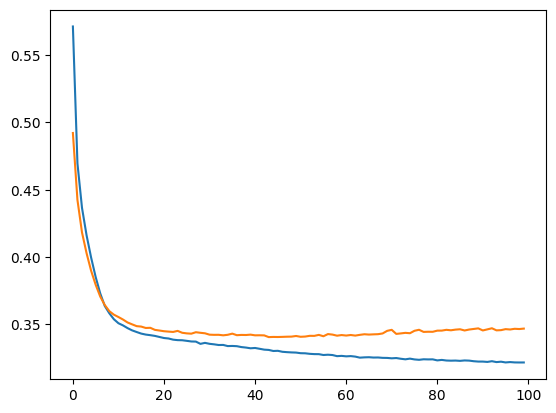

In [88]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')